# Prototype V0.3 - Baseline AI Anomaly Detection

This notebook executes the reproducible V0.3 Isolation Forest workflow through functions in `src/`. DataCo contains an operational `Late_delivery_risk` outcome but no native anomaly or cybersecurity ground truth. The workflow is therefore unsupervised and does not calculate classification metrics.

## 1. Setup and load V0.2 processed data

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import display, Image
from src.ai.model_utils import load_processed_dataco, determine_label_situation, build_feature_manifest
from src.pipeline_v03 import run_baseline_anomaly_detection_v03
bundle = load_processed_dataco()
label_situation = determine_label_situation(bundle)
summary = pd.DataFrame({
    'rows': {name: len(split.features) for name, split in bundle.splits.items()},
    'processed_features': {name: len(bundle.selected_features) for name in bundle.splits},
})
display(summary)
display(label_situation)

,rows,processed_features
train,28000,43
validation,6000,43
test,6000,43


{'case': 'C',
 'kind': 'operational_outcome_only',
 'target': 'Late_delivery_risk',
 'source': 'DataCo Late_delivery_risk operational delivery outcome',
 'supervised_metrics_allowed': False,
 'reason': 'The available target describes late delivery, not an anomaly or cybersecurity attack. It is not used to fit or evaluate V0.3.'}

## 2. Inspect the transparent baseline feature list

The list comes from V0.2 dataset metadata. It excludes identifiers, outcomes, future information, model outputs, and synthetic/blockchain information.

In [2]:
feature_manifest = build_feature_manifest(bundle)
print('Selected features:', feature_manifest['selected_feature_count'])
display(pd.DataFrame({'selected_feature': feature_manifest['selected_features']}))
display(pd.DataFrame(feature_manifest['excluded_features']).head(15))

Selected features: 43


,selected_feature
0,order_item_quantity
1,order_item_product_price
2,product_price
3,order_item_discount
4,order_item_discount_rate
5,order_item_profit_ratio
6,order_item_total
7,days_schedule
8,year
9,month


,column,reason
0,row_id,"Identifier, high-cardinality traceability fiel..."
1,Type,Raw category replaced by train-fitted V0.2 one...
2,Days for shipping (real),Realized or post-outcome field; excluded to pr...
3,Days for shipment (scheduled),Raw source replaced by its controlled V0.2 eng...
4,Benefit per order,Owner-computed aggregate with unclear time win...
5,Sales per customer,Owner-computed aggregate with unclear time win...
6,Delivery Status,Realized or post-outcome field; excluded to pr...
7,Late_delivery_risk,"Operational delivery target, not a cybersecuri..."
8,Category Id,"Identifier, high-cardinality traceability fiel..."
9,Category Name,Not selected for the transparent V0.3 baseline...


## 3. Execute the full V0.3 workflow

The orchestrator builds the sklearn feature-selector/Isolation-Forest pipeline, fits training data only, scores all splits, runs contamination sensitivity and seed stability, measures resources, saves and reloads the model, verifies reloaded inference, audits leakage, and writes every result artifact.

In [3]:
run = run_baseline_anomaly_detection_v03()
report = run['baseline_report']
print('Pipeline steps:', list(run['detector'].pipeline.named_steps))
display(run['model_info'])

Pipeline steps: ['feature_selector', 'isolation_forest']


{'name': 'IsolationForest',
 'artifact_version': 'v0.3',
 'artifact_path': 'E:\\PhD-Blockchain-AI\\models\\isolation_forest_v0_3.joblib',
 'parameters': {'n_estimators': 100,
  'max_samples': 'auto',
  'contamination': 'auto',
  'random_state': 42,
  'n_jobs': 1},
 'random_seed': 42,
 'selected_feature_count': 43,
 'embedded_preprocessing': 'exact V0.2 processed-feature selector',
 'reload_and_inference_verification': 'PASS',
 'additional_models': [],
 'additional_models_note': 'No additional model was added: Isolation Forest is the intentionally simple, computationally bounded primary reference for V0.3.'}

## 4. Anomaly scores, labels, and qualitative inspection

`raw_isolation_score` is lower for more anomalous rows. `anomaly_score=-raw_isolation_score` and its training-bound normalized form are higher for more anomalous rows. Neither is a cybersecurity probability.

{'number_of_samples': 6000,
 'number_of_detected_anomalies': 1819,
 'anomaly_percentage': 30.316666666666666,
 'score_direction': {'raw_isolation_score': 'lower values are more anomalous',
  'anomaly_score': 'higher values are more anomalous (-raw_isolation_score)',
  'normalized_anomaly_score': 'higher values are more anomalous; training-bound min-max score, not a probability'},
 'raw_isolation_score_statistics': {'minimum': -0.5955326136093458,
  'q1': -0.5048877595853999,
  'median': -0.4836607374701094,
  'mean': -0.484925105097967,
  'q3': -0.46383215477297185,
  'maximum': -0.4132781140453749,
  'standard_deviation': 0.029476201912808326},
 'anomaly_score_statistics': {'minimum': 0.4132781140453749,
  'q1': 0.46383215477297185,
  'median': 0.4836607374701094,
  'mean': 0.484925105097967,
  'q3': 0.5048877595853999,
  'maximum': 0.5955326136093458,
  'standard_deviation': 0.029476201912808326}}

,split,row_id,raw_isolation_score,anomaly_score,normalized_anomaly_score,anomaly_label,isolation_forest_prediction,Order Id,Order Item Id,order date (DateOrders),Type,Market,Shipping Mode,Order Item Quantity,Sales,Order Item Total
0,test,160132,-0.595533,0.595533,0.819489,1,-1,74495,177810,12/23/2017 10:33,TRANSFER,Pacific Asia,Standard Class,1,1500.000000,1125.000000
1,test,170841,-0.593964,0.593964,0.812608,1,-1,74552,177867,12/24/2017 6:32,TRANSFER,Pacific Asia,Standard Class,1,1500.000000,1245.000000
2,test,93383,-0.593761,0.593761,0.811717,1,-1,74549,177864,12/24/2017 5:29,DEBIT,Pacific Asia,Standard Class,1,1500.000000,1125.000000
3,test,62856,-0.589633,0.589633,0.793613,1,-1,1725,4299,1/26/2015 3:59,CASH,LATAM,Same Day,1,39.990002,29.990000
4,test,120716,-0.589214,0.589214,0.791776,1,-1,68775,171950,9/30/2017 22:35,TRANSFER,Europe,Standard Class,1,999.989990,899.989990
5,test,146865,-0.582125,0.582125,0.760683,1,-1,45627,114039,10/28/2016 0:49,PAYMENT,Pacific Asia,Same Day,1,399.980011,299.989990
6,test,140597,-0.580600,0.580600,0.753996,1,-1,70674,173989,10/28/2017 15:53,CASH,Europe,Standard Class,1,1500.000000,1275.000000
7,test,69172,-0.577624,0.577624,0.740942,1,-1,27591,69068,2/7/2016 18:00,PAYMENT,Pacific Asia,Same Day,5,250.000000,200.000000
8,test,28808,-0.577550,0.577550,0.740617,1,-1,45321,113239,10/23/2016 13:36,PAYMENT,Africa,First Class,5,499.950012,419.959992
9,test,38479,-0.577130,0.577130,0.738776,1,-1,70509,173824,10/26/2017 6:05,PAYMENT,Europe,Standard Class,1,1500.000000,1230.000000


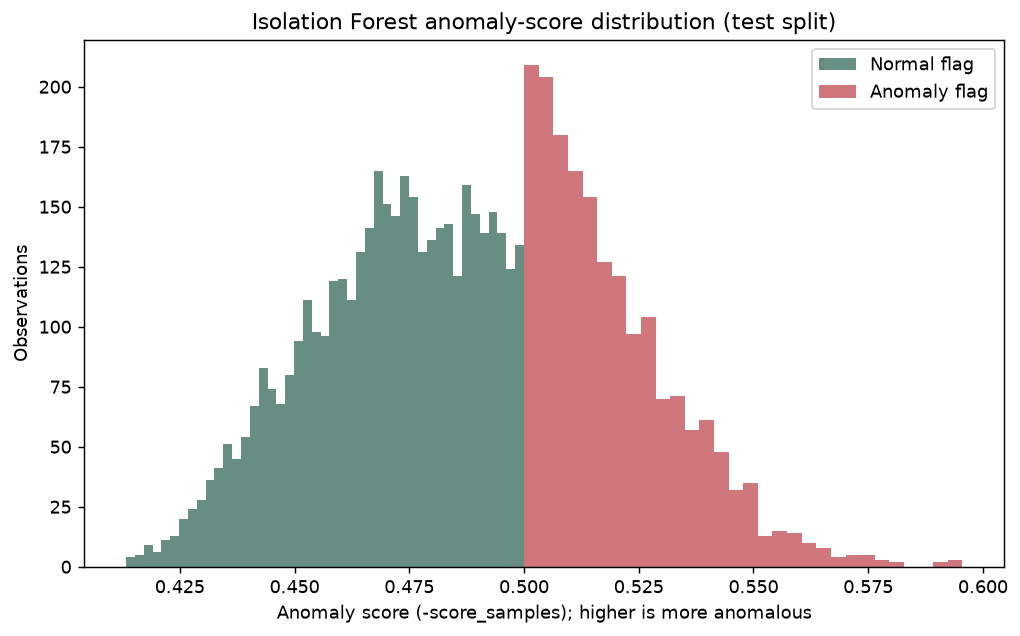

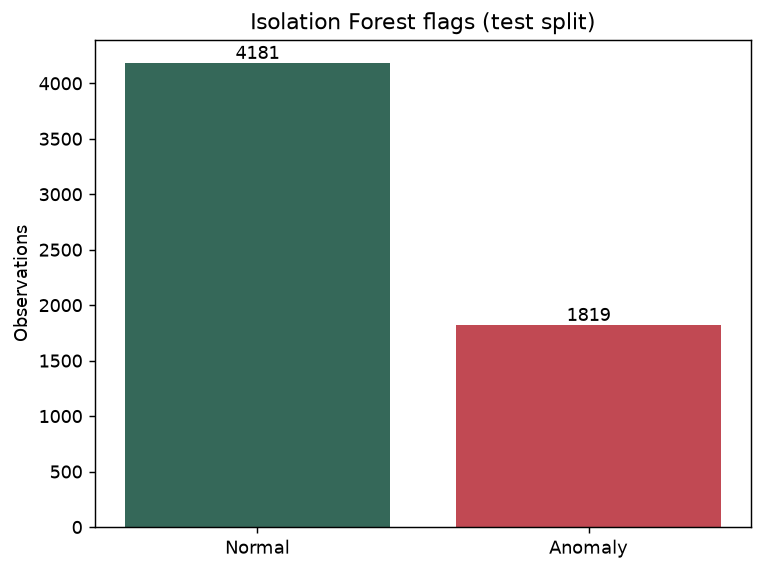

In [4]:
display(report['anomaly_detection'])
display(run['top_anomalies'].head(10))
display(Image(filename=str(run['paths']['figures'][0])))
display(Image(filename=str(run['paths']['figures'][1])))

## 5. Contamination sensitivity and random-seed stability

Contamination values are sensitivity assumptions, not estimates or ground truth. Stability compares test flags and score ranks with seed 42.

,contamination,split,number_of_samples,number_of_detected_anomalies,anomaly_percentage,training_time_seconds,inference_time_seconds,interpretation
0,0.01,validation,6000,31,0.516667,0.520138,0.044384,"sensitivity assumption, not ground truth preva..."
1,0.01,test,6000,31,0.516667,0.520138,0.042778,"sensitivity assumption, not ground truth preva..."
2,0.03,validation,6000,119,1.983333,0.624086,0.037408,"sensitivity assumption, not ground truth preva..."
3,0.03,test,6000,109,1.816667,0.624086,0.036552,"sensitivity assumption, not ground truth preva..."
4,0.05,validation,6000,200,3.333333,0.488258,0.037639,"sensitivity assumption, not ground truth preva..."
5,0.05,test,6000,209,3.483333,0.488258,0.042090,"sensitivity assumption, not ground truth preva..."
6,0.10,validation,6000,431,7.183333,0.642528,0.085217,"sensitivity assumption, not ground truth preva..."
7,0.10,test,6000,438,7.300000,0.642528,0.057454,"sensitivity assumption, not ground truth preva..."


,seed,reference_seed,number_of_detected_anomalies,anomaly_percentage,jaccard_with_reference,score_rank_correlation_with_reference,fit_and_inference_time_seconds
0,42,42,1819,30.316667,1.000000,1.000000,0.876190
1,43,42,1650,27.500000,0.648764,0.907161,0.611159
2,44,42,1697,28.283333,0.679083,0.902379,0.527101


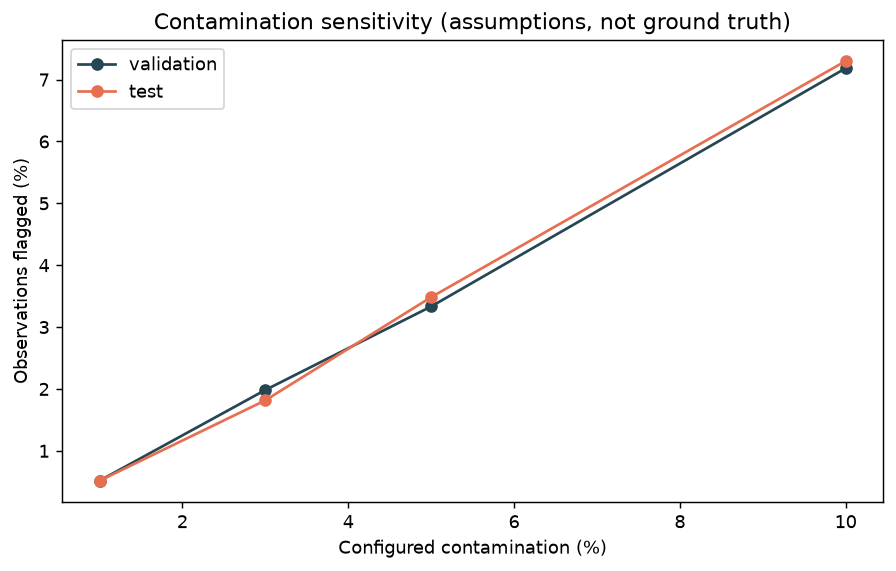

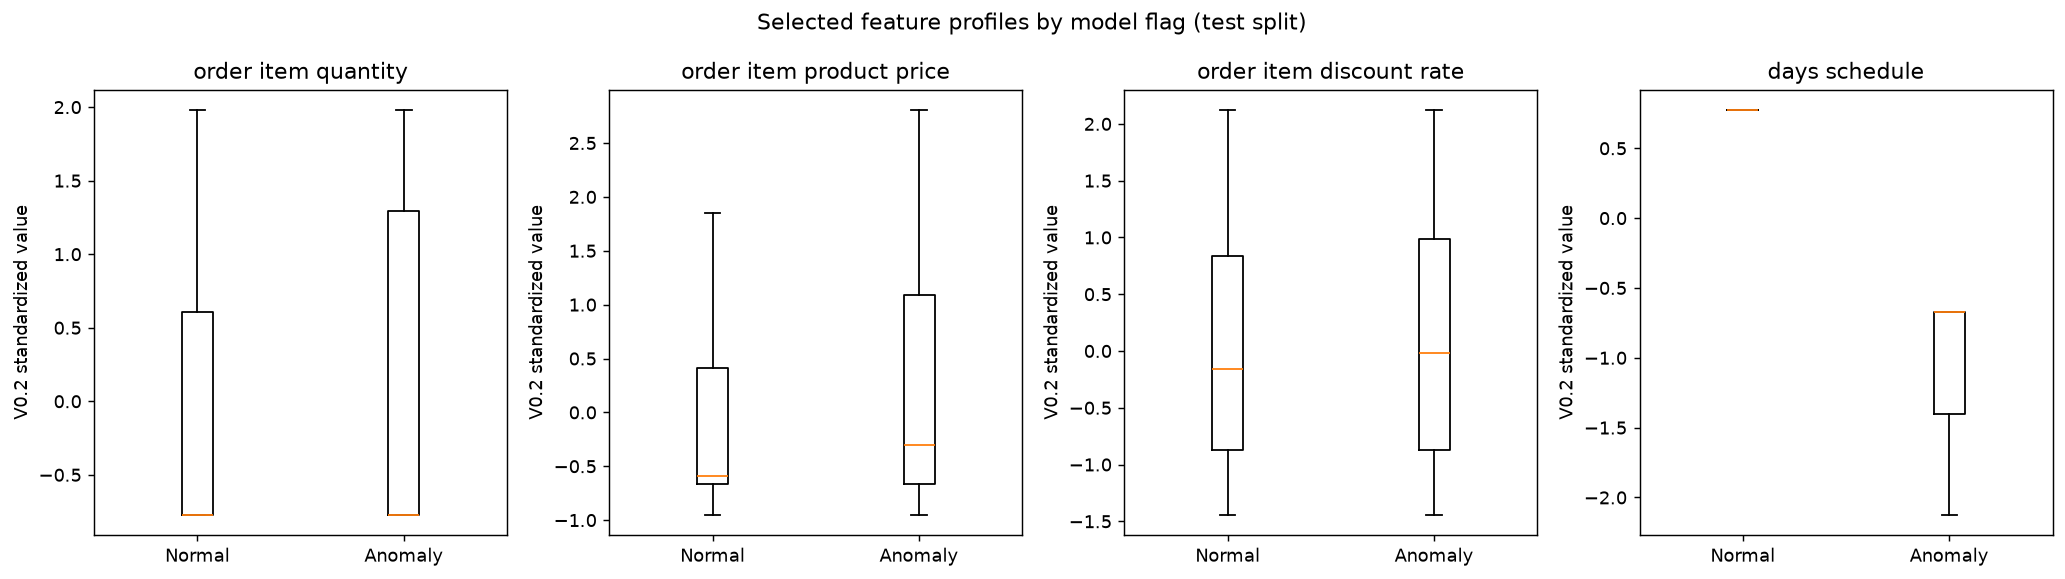

In [5]:
display(run['sensitivity'])
display(run['stability'])
display(Image(filename=str(run['paths']['figures'][2])))
display(Image(filename=str(run['paths']['figures'][3])))

## 6. Evaluation, resources, leakage, and reproducibility

In [6]:
print('Supervised metrics calculated:', run['metrics']['supervised_metrics']['calculated'])
display(run['metrics']['performance'])
display(run['leakage_audit'])
print('Saved-model reload:', run['model_info']['reload_and_inference_verification'])

Supervised metrics calculated: False


{'training_time_seconds': 0.589866,
 'inference_time_seconds_all_splits': 0.493217,
 'total_execution_time_seconds': 9.052298599970527,
 'training_measurement': {'wall_time_seconds': 0.589866,
  'cpu_time_seconds': 0.4375,
  'avg_cpu_percent': 71.13,
  'peak_cpu_percent': 153.8,
  'peak_memory_rss_bytes': 276623360,
  'start_memory_rss_bytes': 263344128,
  'end_memory_rss_bytes': 267202560,
  'sample_count': 30},
 'inference_measurements': {'train': {'wall_time_seconds': 0.327538,
   'cpu_time_seconds': 0.328125,
   'avg_cpu_percent': 95.57,
   'peak_cpu_percent': 153.4,
   'peak_memory_rss_bytes': 256909312,
   'start_memory_rss_bytes': 238919680,
   'end_memory_rss_bytes': 247259136,
   'sample_count': 18},
  'validation': {'wall_time_seconds': 0.083127,
   'cpu_time_seconds': 0.078125,
   'avg_cpu_percent': 76.08,
   'peak_cpu_percent': 152.1,
   'peak_memory_rss_bytes': 250368000,
   'start_memory_rss_bytes': 249634816,
   'end_memory_rss_bytes': 250351616,
   'sample_count': 6},
 

{'stage': 'V0.3',
 'overall_status': 'PASS',
 'checks': {'target_not_in_features': {'status': 'PASS', 'evidence': []},
  'identifiers_not_in_features': {'status': 'PASS', 'evidence': []},
  'post_outcome_variables_not_in_features': {'status': 'PASS', 'evidence': []},
  'preprocessing_fitted_on_training_only': {'status': 'PASS',
   'evidence': {'preprocessor_fitted_rows': 28000,
    'training_rows': 28000,
    'order_id_overlap': {'train_vs_validation': 0,
     'train_vs_test': 0,
     'validation_vs_test': 0}}},
  'model_outputs_not_in_features': {'status': 'PASS', 'evidence': []},
  'future_information_not_in_features': {'status': 'PASS', 'evidence': []}},
 'note': 'The operational Late_delivery_risk files are retained for provenance only and are not loaded into the model feature pipeline or used for V0.3 metrics.'}

Saved-model reload: PASS


## 7. Final baseline summary and artifacts

In [7]:
final_summary = {
    'status': report['status'],
    'samples': report['dataset']['number_of_samples'],
    'features': report['dataset']['number_of_features'],
    'test_anomalies': report['anomaly_detection']['number_of_detected_anomalies'],
    'test_anomaly_percentage': report['anomaly_detection']['anomaly_percentage'],
    'leakage_audit': report['leakage_audit'],
    'model_artifact': str(run['paths']['model']),
}
display(final_summary)
print(report['research_interpretation'])
print('Limitations:')
for limitation in report['limitations']:
    print('-', limitation)

{'status': 'PASS',
 'samples': 40000,
 'features': 43,
 'test_anomalies': 1819,
 'test_anomaly_percentage': 30.316666666666666,
 'leakage_audit': 'PASS',
 'model_artifact': 'E:\\PhD-Blockchain-AI\\models\\isolation_forest_v0_3.joblib'}

The V0.3 baseline establishes a reproducible anomaly-detection reference point for subsequent optimization and lightweight-model experiments.
Limitations:
- DataCo has no native cybersecurity or anomaly ground-truth labels.
- Isolation Forest is unsupervised; its flags are not confirmed attacks.
- Contamination scenarios are assumptions, not measured prevalence.
- Anomaly interpretation is operational/business-oriented and requires domain review.
- The V0.2 processed experiment uses a deterministic 40,000-row cap.
